In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

BASE         = 'C:/Users/Saurabh yadav/Documents/Patient Readmission Risk Analysis/'
DATA_PATH    = BASE + 'data/diabetic_data.csv'
OUTPUT_PATH  = BASE + 'outputs/'
TABLEAU_PATH = BASE + 'tableau/'

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(TABLEAU_PATH, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150

print('Libraries loaded')
print('Base folder:', BASE)
print('Output folder ready')
print('Tableau folder ready')

Libraries loaded
Base folder: C:/Users/Saurabh yadav/Documents/Patient Readmission Risk Analysis/
Output folder ready
Tableau folder ready


In [2]:
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print()
print('Missing values:')
missing = df.isin(['?']).sum()
missing = missing[missing > 0]
print(missing)
print()
print('Readmission distribution:')
print(df['readmitted'].value_counts())

Shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Missing values:
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
d

In [3]:
df = df.replace('?', np.nan)

df = df.drop(columns=['weight','payer_code','medical_specialty'], errors='ignore')

df = df.drop_duplicates(subset='patient_nbr', keep='first')

df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

df['age_numeric'] = df['age'].str.extract(r'(\d+)').astype(float) + 5

df['stay_category'] = pd.cut(df['time_in_hospital'],
    bins=[0, 3, 7, 14],
    labels=['Short (1-3)', 'Medium (4-7)', 'Long (8-14)'])

df['medication_count_category'] = pd.cut(df['num_medications'],
    bins=[0, 10, 20, 100],
    labels=['Low', 'Medium', 'High'])

df['total_visits'] = (
    df['number_outpatient'] +
    df['number_inpatient'] +
    df['number_emergency']
)

df = df.dropna(subset=['readmitted','gender','age'])

print('Cleaned shape:', df.shape)
print('Readmission rate (within 30 days):',
      round(df['readmitted_binary'].mean() * 100, 2), '%')
print()
print('New features added:')
print(' - readmitted_binary')
print(' - age_numeric')
print(' - stay_category')
print(' - medication_count_category')
print(' - total_visits')

Cleaned shape: (71518, 52)
Readmission rate (within 30 days): 8.8 %

New features added:
 - readmitted_binary
 - age_numeric
 - stay_category
 - medication_count_category
 - total_visits


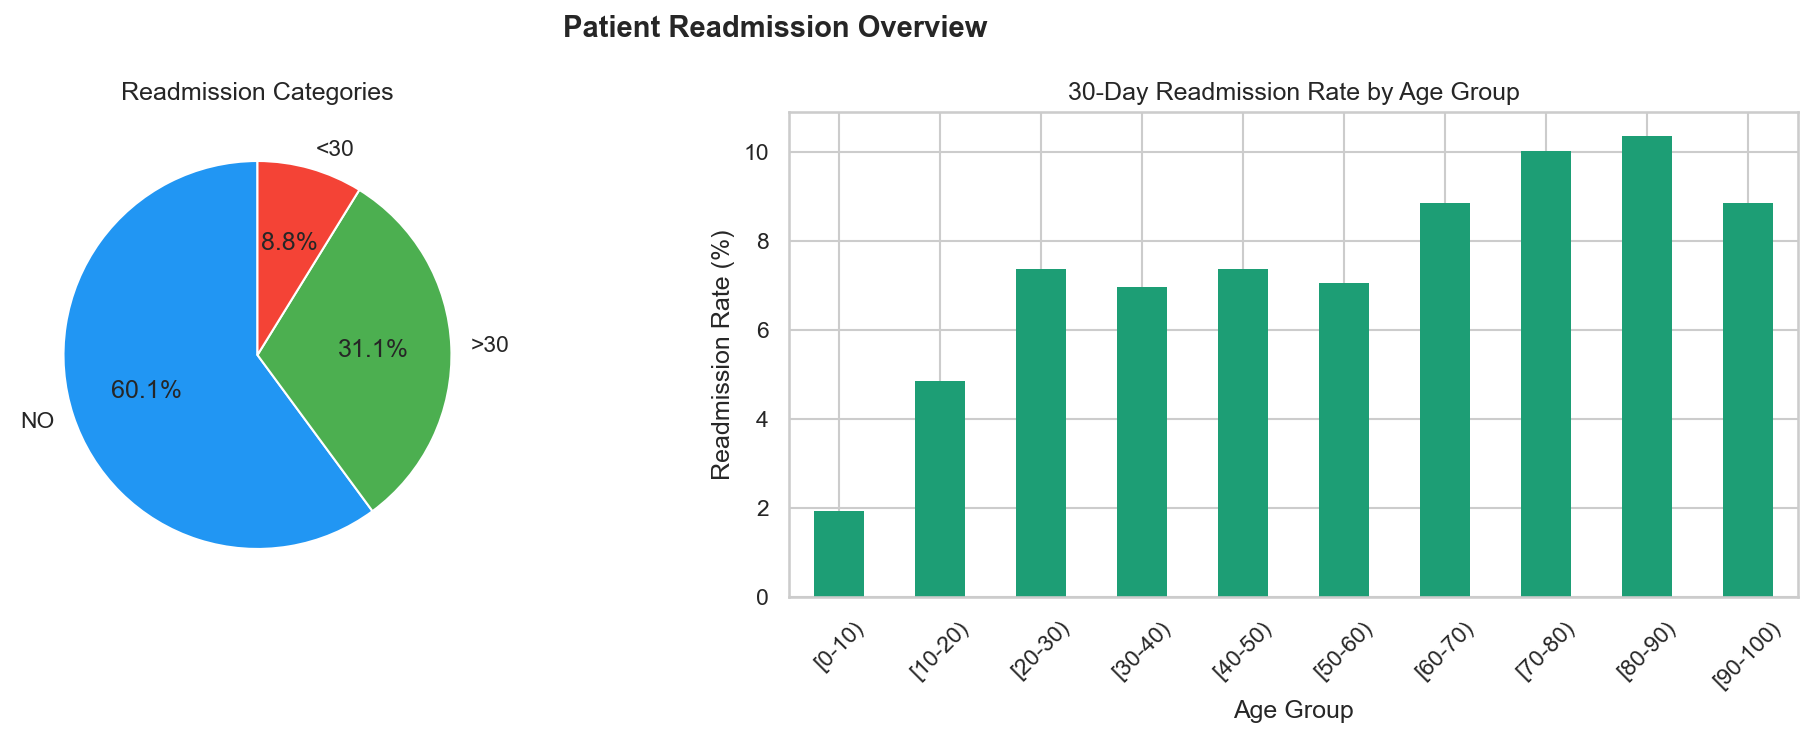

Chart 1 saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Patient Readmission Overview', fontsize=14, fontweight='bold')

counts = df['readmitted'].value_counts()
colors = ['#2196F3','#4CAF50','#F44336']
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Readmission Categories')

readmit_by_age = df.groupby('age')['readmitted_binary'].mean().mul(100)
readmit_by_age.plot(kind='bar', ax=axes[1], color='#1D9E75', edgecolor='none')
axes[1].set_title('30-Day Readmission Rate by Age Group')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_xlabel('Age Group')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'chart1_readmission_overview.png', bbox_inches='tight')
plt.show()
print('Chart 1 saved')

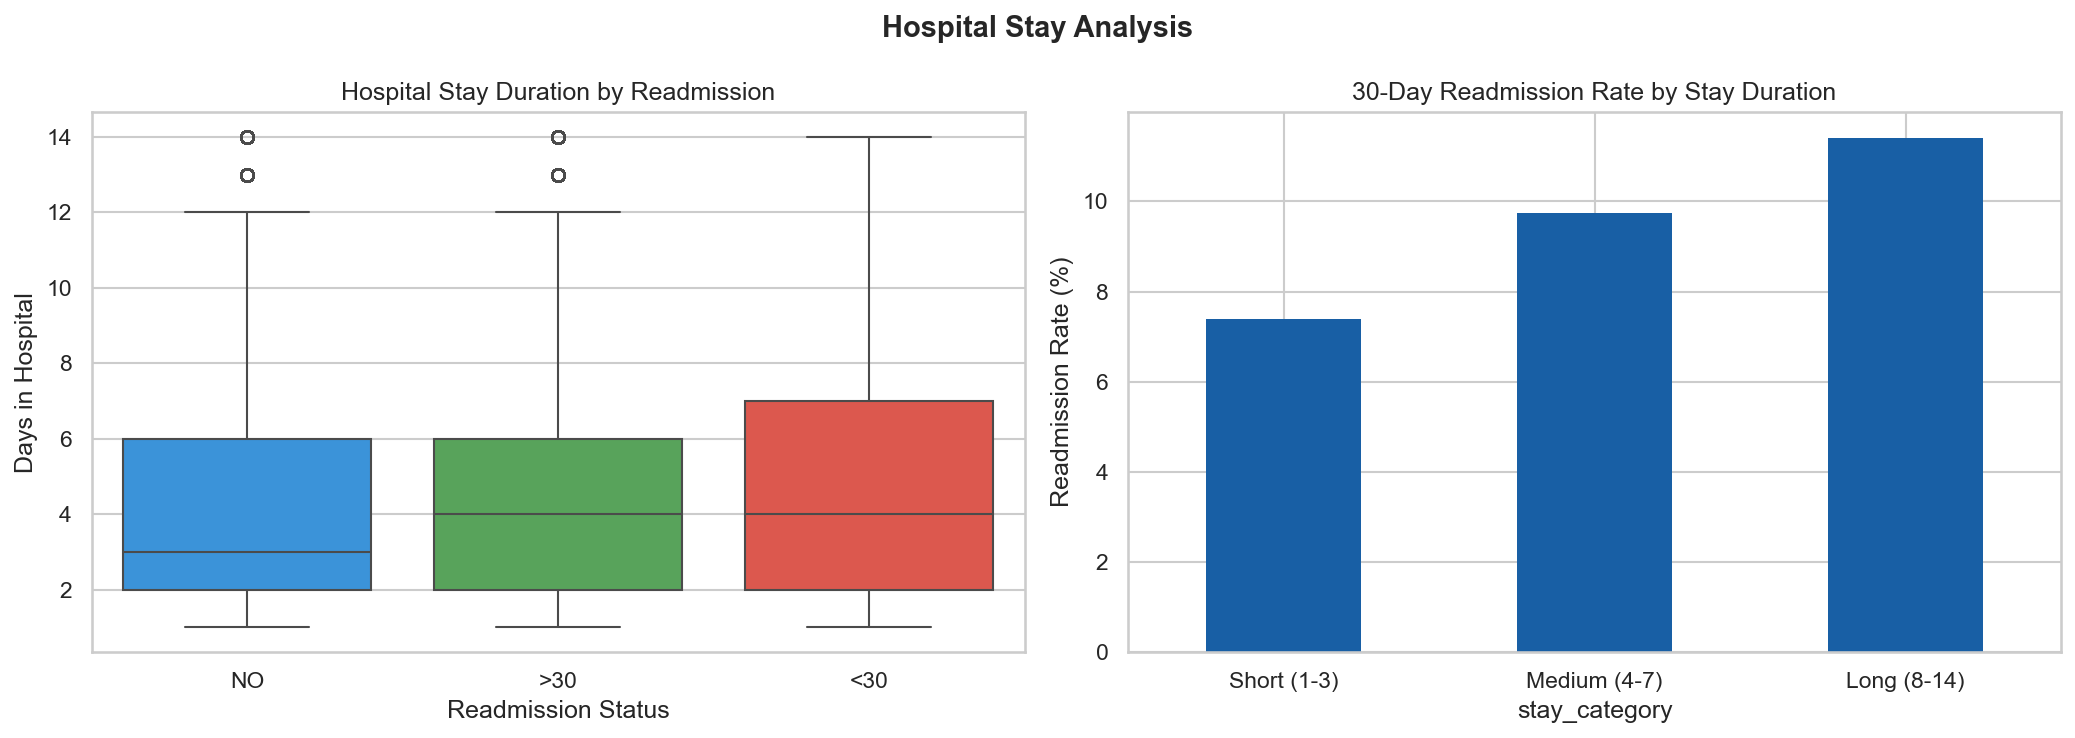

Chart 2 saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hospital Stay Analysis', fontsize=14, fontweight='bold')

sns.boxplot(data=df, x='readmitted', y='time_in_hospital',
            palette=['#2196F3','#4CAF50','#F44336'], ax=axes[0])
axes[0].set_title('Hospital Stay Duration by Readmission')
axes[0].set_xlabel('Readmission Status')
axes[0].set_ylabel('Days in Hospital')

stay_readmit = df.groupby('stay_category')['readmitted_binary'].mean().mul(100)
stay_readmit.plot(kind='bar', ax=axes[1], color='#185FA5', edgecolor='none')
axes[1].set_title('30-Day Readmission Rate by Stay Duration')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'chart2_hospital_stay.png', bbox_inches='tight')
plt.show()
print('Chart 2 saved')

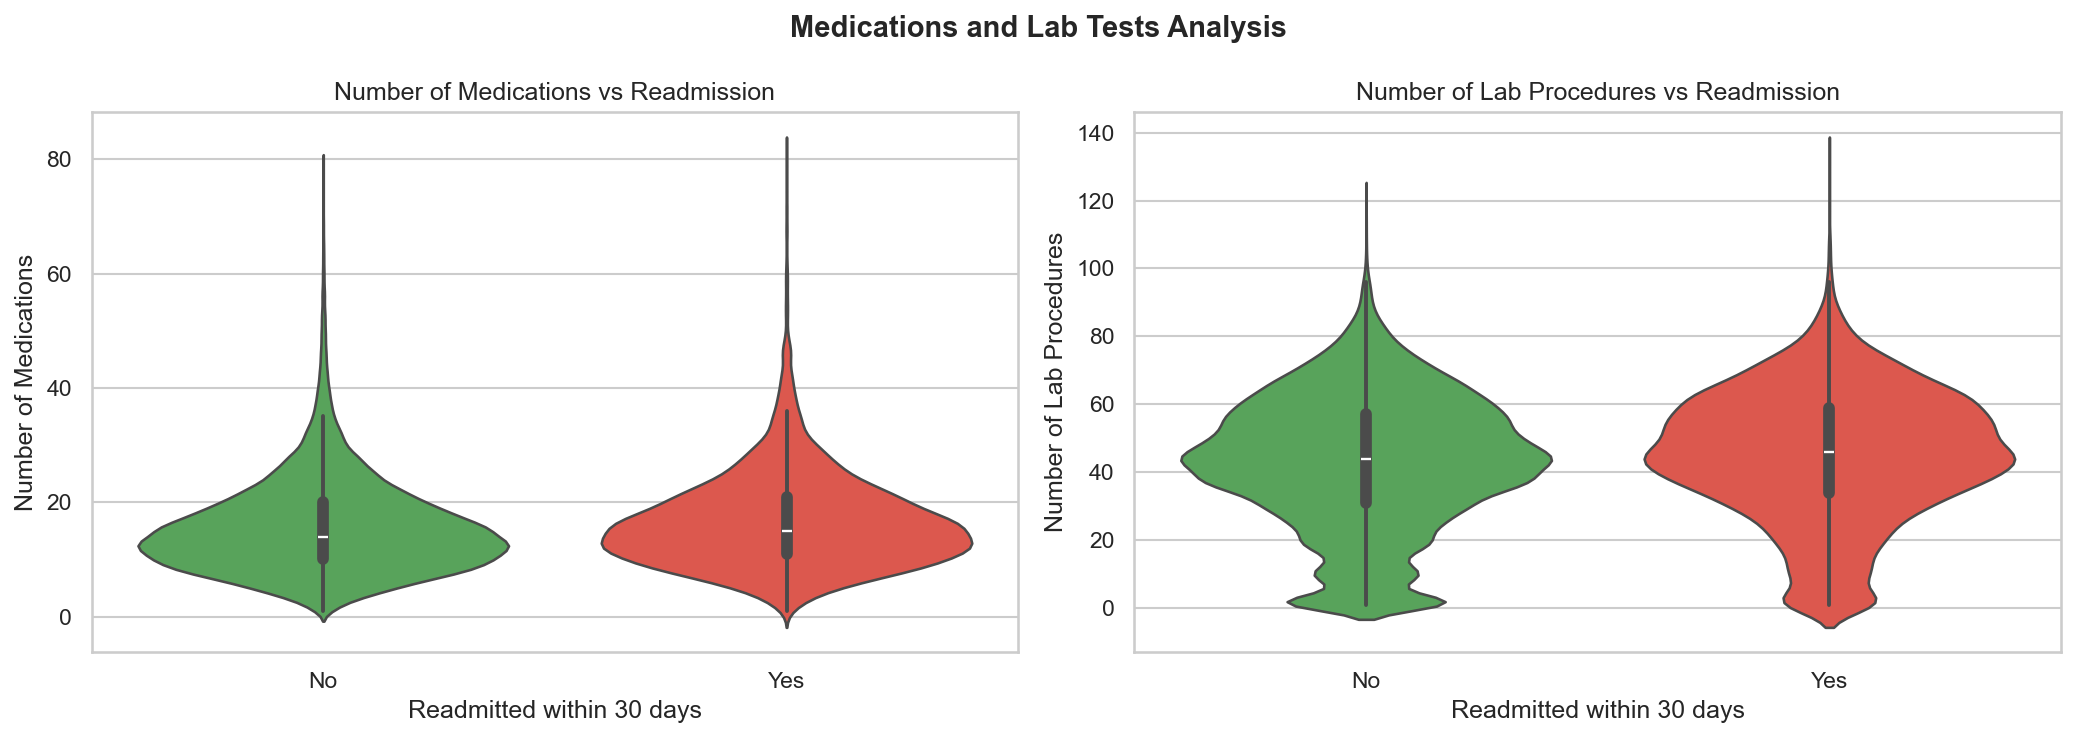

Chart 3 saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Medications and Lab Tests Analysis', fontsize=14, fontweight='bold')

sns.violinplot(data=df, x='readmitted_binary', y='num_medications',
               palette=['#4CAF50','#F44336'], ax=axes[0])
axes[0].set_title('Number of Medications vs Readmission')
axes[0].set_xlabel('Readmitted within 30 days')
axes[0].set_ylabel('Number of Medications')
axes[0].set_xticklabels(['No','Yes'])

sns.violinplot(data=df, x='readmitted_binary', y='num_lab_procedures',
               palette=['#4CAF50','#F44336'], ax=axes[1])
axes[1].set_title('Number of Lab Procedures vs Readmission')
axes[1].set_xlabel('Readmitted within 30 days')
axes[1].set_ylabel('Number of Lab Procedures')
axes[1].set_xticklabels(['No','Yes'])

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'chart3_medications_labs.png', bbox_inches='tight')
plt.show()
print('Chart 3 saved')

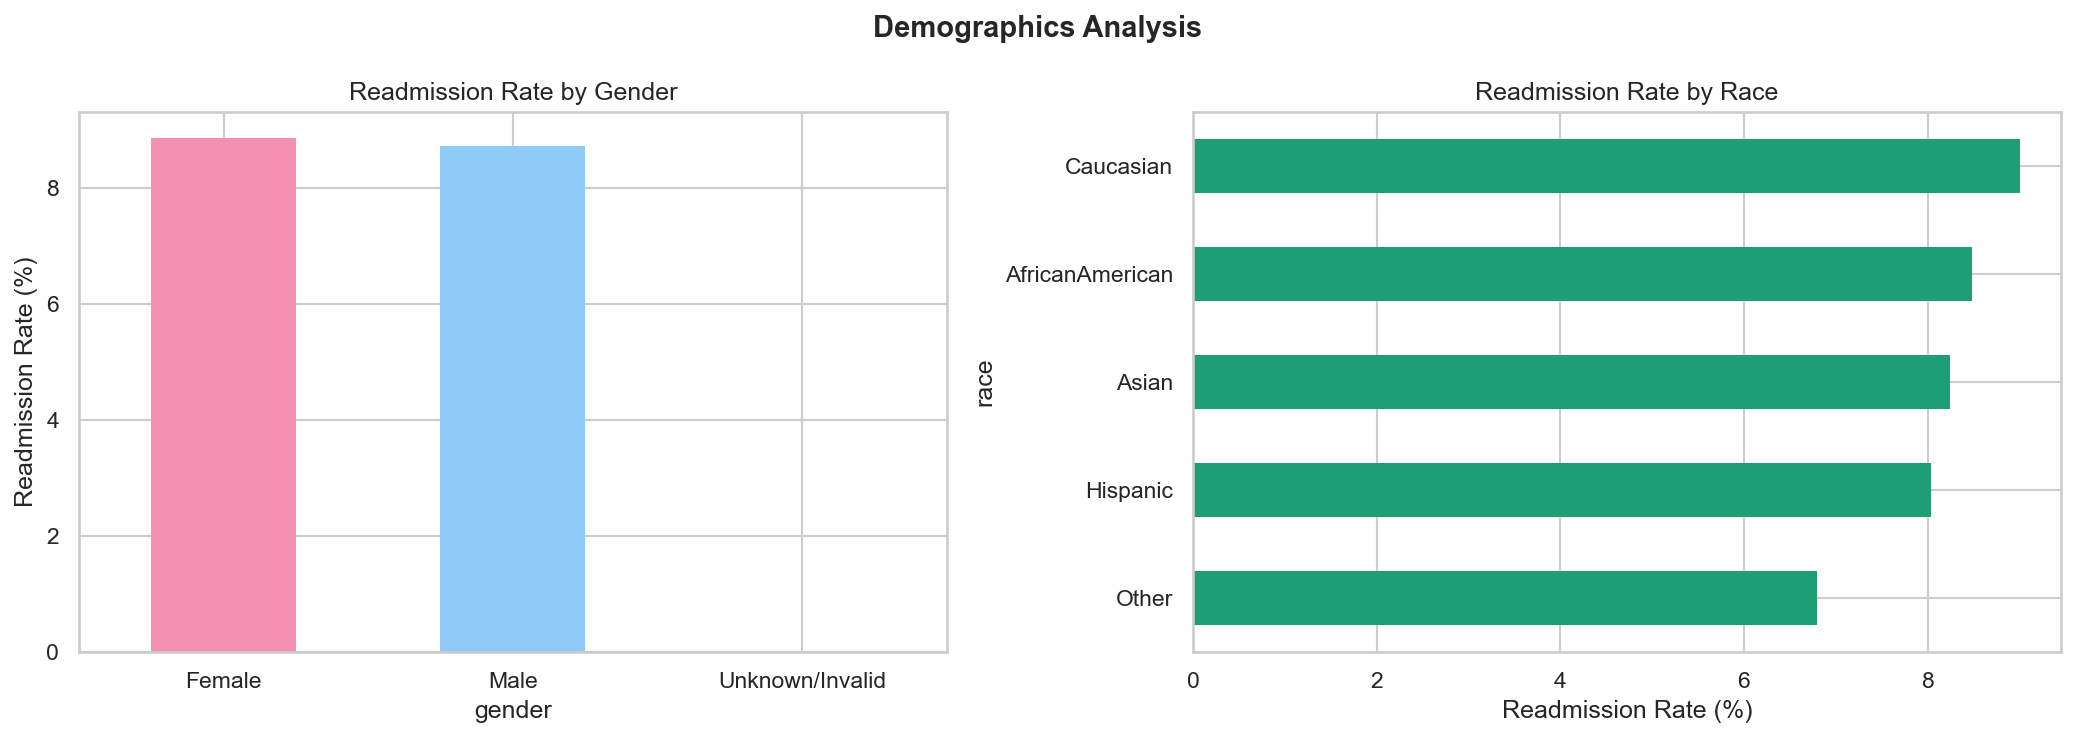

Chart 4 saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Demographics Analysis', fontsize=14, fontweight='bold')

gender_readmit = df.groupby('gender')['readmitted_binary'].mean().mul(100)
gender_readmit.plot(kind='bar', ax=axes[0],
                    color=['#F48FB1','#90CAF9'], edgecolor='none')
axes[0].set_title('Readmission Rate by Gender')
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

race_readmit = df.groupby('race')['readmitted_binary'].mean().mul(100).sort_values()
race_readmit.plot(kind='barh', ax=axes[1], color='#1D9E75', edgecolor='none')
axes[1].set_title('Readmission Rate by Race')
axes[1].set_xlabel('Readmission Rate (%)')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'chart4_demographics.png', bbox_inches='tight')
plt.show()
print('Chart 4 saved')

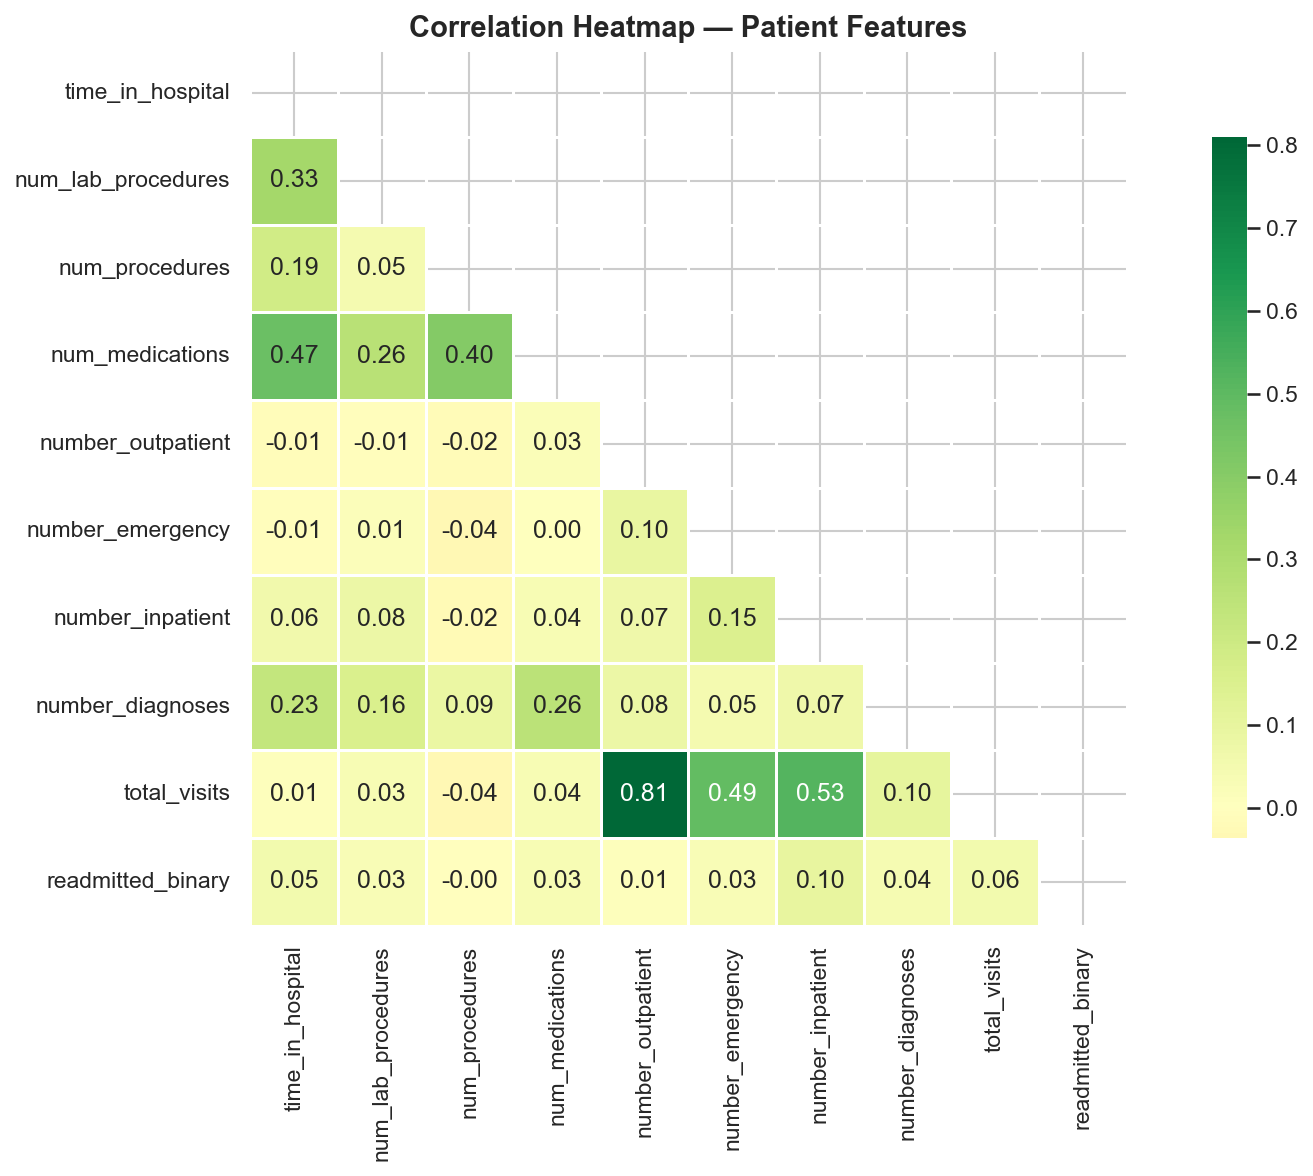

Chart 5 saved


In [8]:
numeric_cols = [
    'time_in_hospital','num_lab_procedures','num_procedures',
    'num_medications','number_outpatient','number_emergency',
    'number_inpatient','number_diagnoses','total_visits','readmitted_binary'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Patient Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'chart5_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Chart 5 saved')

In [4]:
import pandas as pd
import os

base = r"C:\Users\Saurabh yadav\Documents\Patient Readmission Risk Analysis"
DATA_PATH    = base + r"\data\\"
TABLEAU_PATH = base + r"\tableau\\"
os.makedirs(TABLEAU_PATH, exist_ok=True)

# Load raw data
df = pd.read_csv(DATA_PATH + "diabetic_data.csv")
df = df.replace("?", pd.NA)

# Recreate engineered columns
df['age_numeric'] = df['age'].str.extract(r'(\d+)').astype(float)
df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

df['stay_category'] = pd.cut(df['time_in_hospital'],
    bins=[0,3,7,14], labels=['Short','Medium','Long'])

df['medication_count_category'] = pd.cut(df['num_medications'],
    bins=[0,10,20,100], labels=['Low','Medium','High'])

# Save for Tableau
tableau_cols = [
    'race','gender','age','age_numeric','time_in_hospital',
    'num_lab_procedures','num_procedures','num_medications',
    'number_outpatient','number_emergency','number_inpatient',
    'number_diagnoses','total_visits','stay_category',
    'medication_count_category','readmitted','readmitted_binary'
]

tableau_df = df[tableau_cols].copy()
tableau_df['stay_category'] = tableau_df['stay_category'].astype(str)
tableau_df['medication_count_category'] = tableau_df['medication_count_category'].astype(str)
tableau_df.to_csv(TABLEAU_PATH + 'clean_patients.csv', index=False)

print("File saved!")
print("Rows:", len(tableau_df))
print("Location:", TABLEAU_PATH + "clean_patients.csv")

File saved!
Rows: 101766
Location: C:\Users\Saurabh yadav\Documents\Patient Readmission Risk Analysis\tableau\\clean_patients.csv
